# Analise Exploratoria de Dados (EDA)
## Financial Asset Price Forecasting

> **Objetivo:** Entender a estrutura, distribuicao e relacoes dos ativos antes de construir o pipeline de ML.
>
> **Ativos:** RACE (Ferrari), AAPL (Apple), NVDA (Nvidia), VALE3.SA, ITSA4.SA, WEGE3.SA, ^GSPC

---

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
COLORS = ["#00D4FF","#FF6B6B","#51CF66","#FFD43B","#CC5DE8","#FF922B","#74C0FC"]
pd.set_option("display.float_format", "{:.4f}".format)
print("Ambiente OK!")


Ambiente OK!


---
## 1. Coleta de Dados

In [2]:
TICKERS = {
    "RACE":     "Ferrari N.V.",
    "AAPL":     "Apple Inc.",
    "NVDA":     "Nvidia Corp.",
    "VALE3.SA": "Vale S.A.",
    "ITSA4.SA": "Itausa S.A.",
    "WEGE3.SA": "WEG S.A.",
    "^GSPC":    "SP500 Index"
}

raw = {}
for ticker, name in TICKERS.items():
    df = yf.Ticker(ticker).history(period="max", interval="1d")
    df.index = pd.to_datetime(df.index).tz_localize(None)
    raw[ticker] = df
    print(f"  {ticker:12} | {name:22} | {len(df):5} dias | {df.index.min().date()} -> {df.index.max().date()}")

print(f"Total de ativos: {len(raw)}")


  RACE         | Ferrari N.V.           |  2652 dias | 2015-10-21 -> 2026-05-08
  AAPL         | Apple Inc.             | 11443 dias | 1980-12-12 -> 2026-05-08
  NVDA         | Nvidia Corp.           |  6866 dias | 1999-01-22 -> 2026-05-08
  VALE3.SA     | Vale S.A.              |  6613 dias | 2000-01-03 -> 2026-05-08
  ITSA4.SA     | Itausa S.A.            |  6613 dias | 2000-01-03 -> 2026-05-08
  WEGE3.SA     | WEG S.A.               |  6613 dias | 2000-01-03 -> 2026-05-08
  ^GSPC        | SP500 Index            | 24705 dias | 1927-12-30 -> 2026-05-08
Total de ativos: 7


---
## 2. Inspecao Inicial — Shape e Nulos

In [3]:
rows = []
for ticker, df in raw.items():
    rows.append({
        "Ticker": ticker,
        "Nome": TICKERS[ticker],
        "Registros": len(df),
        "Inicio": str(df.index.min().date()),
        "Fim": str(df.index.max().date()),
        "Nulos (%)": round(df.isnull().mean().mean()*100, 2),
        "Close Min": round(df["Close"].min(), 2),
        "Close Max": round(df["Close"].max(), 2),
        "Close Atual": round(df["Close"].iloc[-1], 2),
    })
pd.DataFrame(rows).set_index("Ticker")


,Nome,Registros,Inicio,Fim,Nulos (%),Close Min,Close Max,Close Atual
Ticker,,,,,,,,
RACE,Ferrari N.V.,2652,2015-10-21,2026-05-08,0.0000,29.2500,511.7400,339.6900
AAPL,Apple Inc.,11443,1980-12-12,2026-05-08,0.0000,0.0400,293.3200,293.3200
NVDA,Nvidia Corp.,6866,1999-01-22,2026-05-08,0.0000,0.0300,216.6100,215.2000
VALE3.SA,Vale S.A.,6613,2000-01-03,2026-05-08,0.0000,1.0400,90.0900,80.8000
ITSA4.SA,Itausa S.A.,6613,2000-01-03,2026-05-08,0.0000,0.2100,15.0000,13.5000
WEGE3.SA,WEG S.A.,6613,2000-01-03,2026-05-08,0.0000,0.0900,55.3100,45.5200
^GSPC,SP500 Index,24705,1927-12-30,2026-05-08,0.0000,4.4000,7398.9300,7398.9300


---
## 3. Evolucao Historica dos Precos


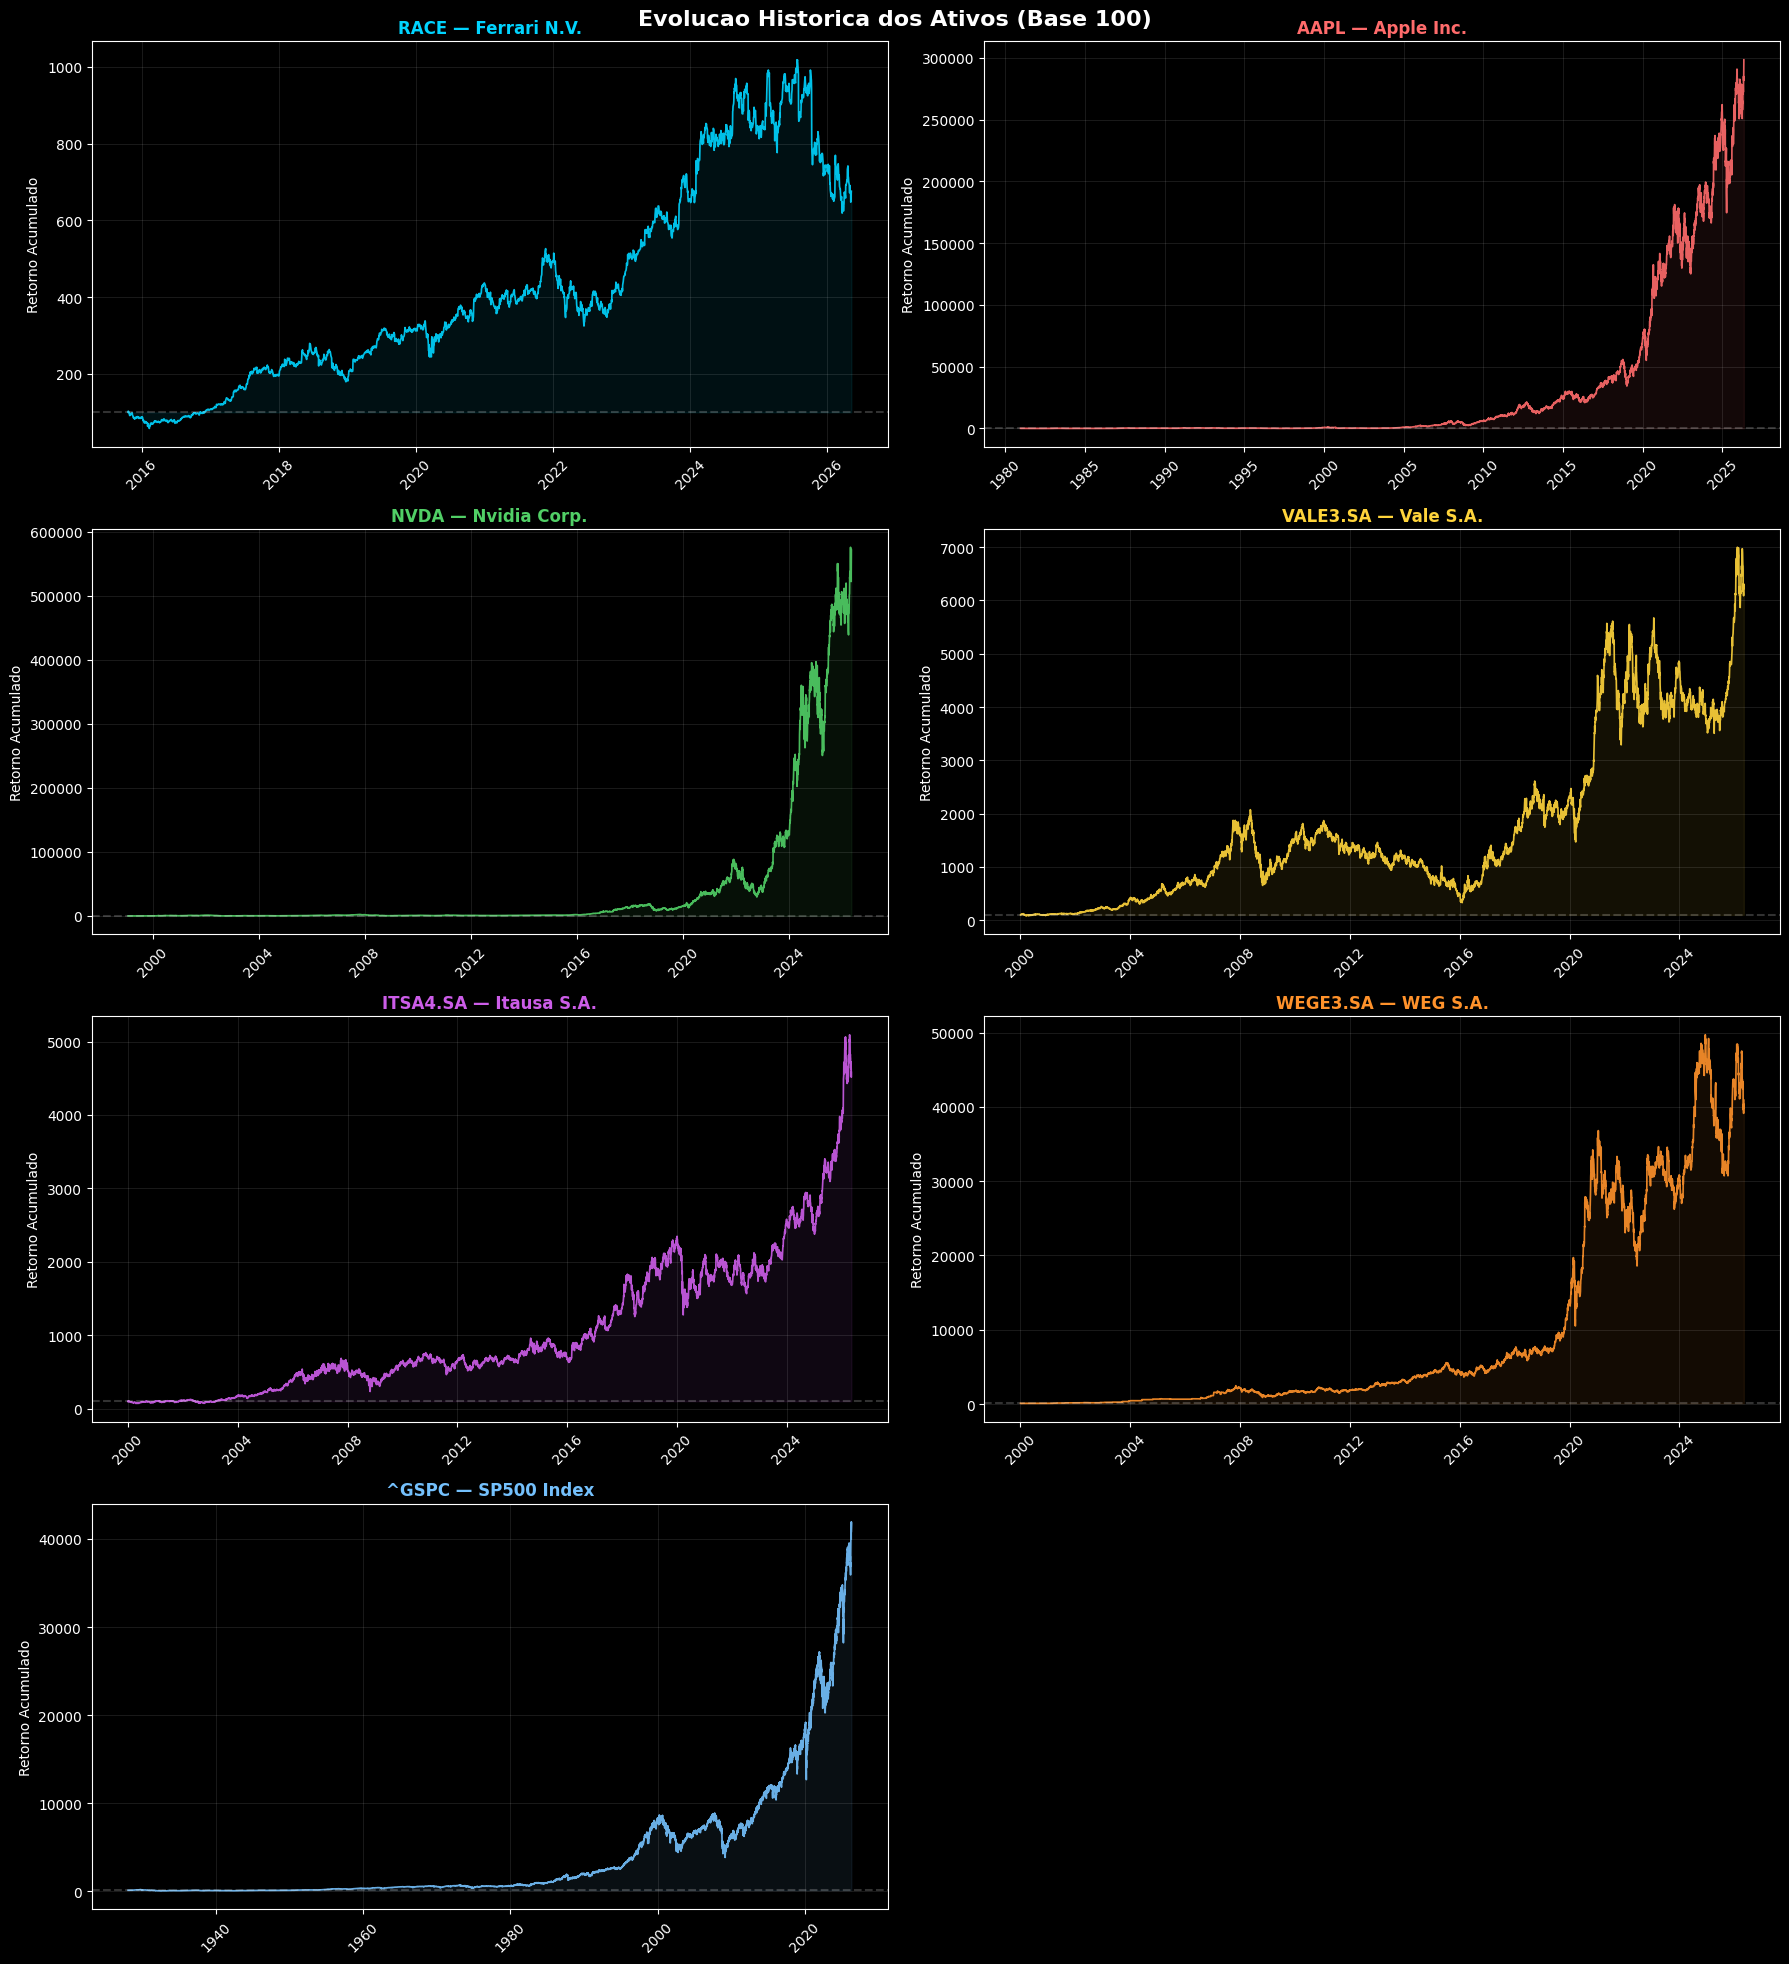

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()
for i, (ticker, df) in enumerate(raw.items()):
    ax = axes[i]
    close = df["Close"].dropna()
    norm = (close / close.iloc[0]) * 100
    ax.plot(close.index, norm, color=COLORS[i], linewidth=1.2, alpha=0.9)
    ax.fill_between(close.index, norm, 100, alpha=0.08, color=COLORS[i])
    ax.set_title(f"{ticker} — {TICKERS[ticker]}", fontsize=12, fontweight="bold", color=COLORS[i])
    ax.set_ylabel("Retorno Acumulado")
    ax.axhline(100, color="white", alpha=0.2, linestyle="--")
    ax.grid(alpha=0.1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
axes[-1].set_visible(False)
fig.suptitle("Evolucao Historica dos Ativos (Base 100)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 4. Distribuicao dos Retornos Logaritmicos

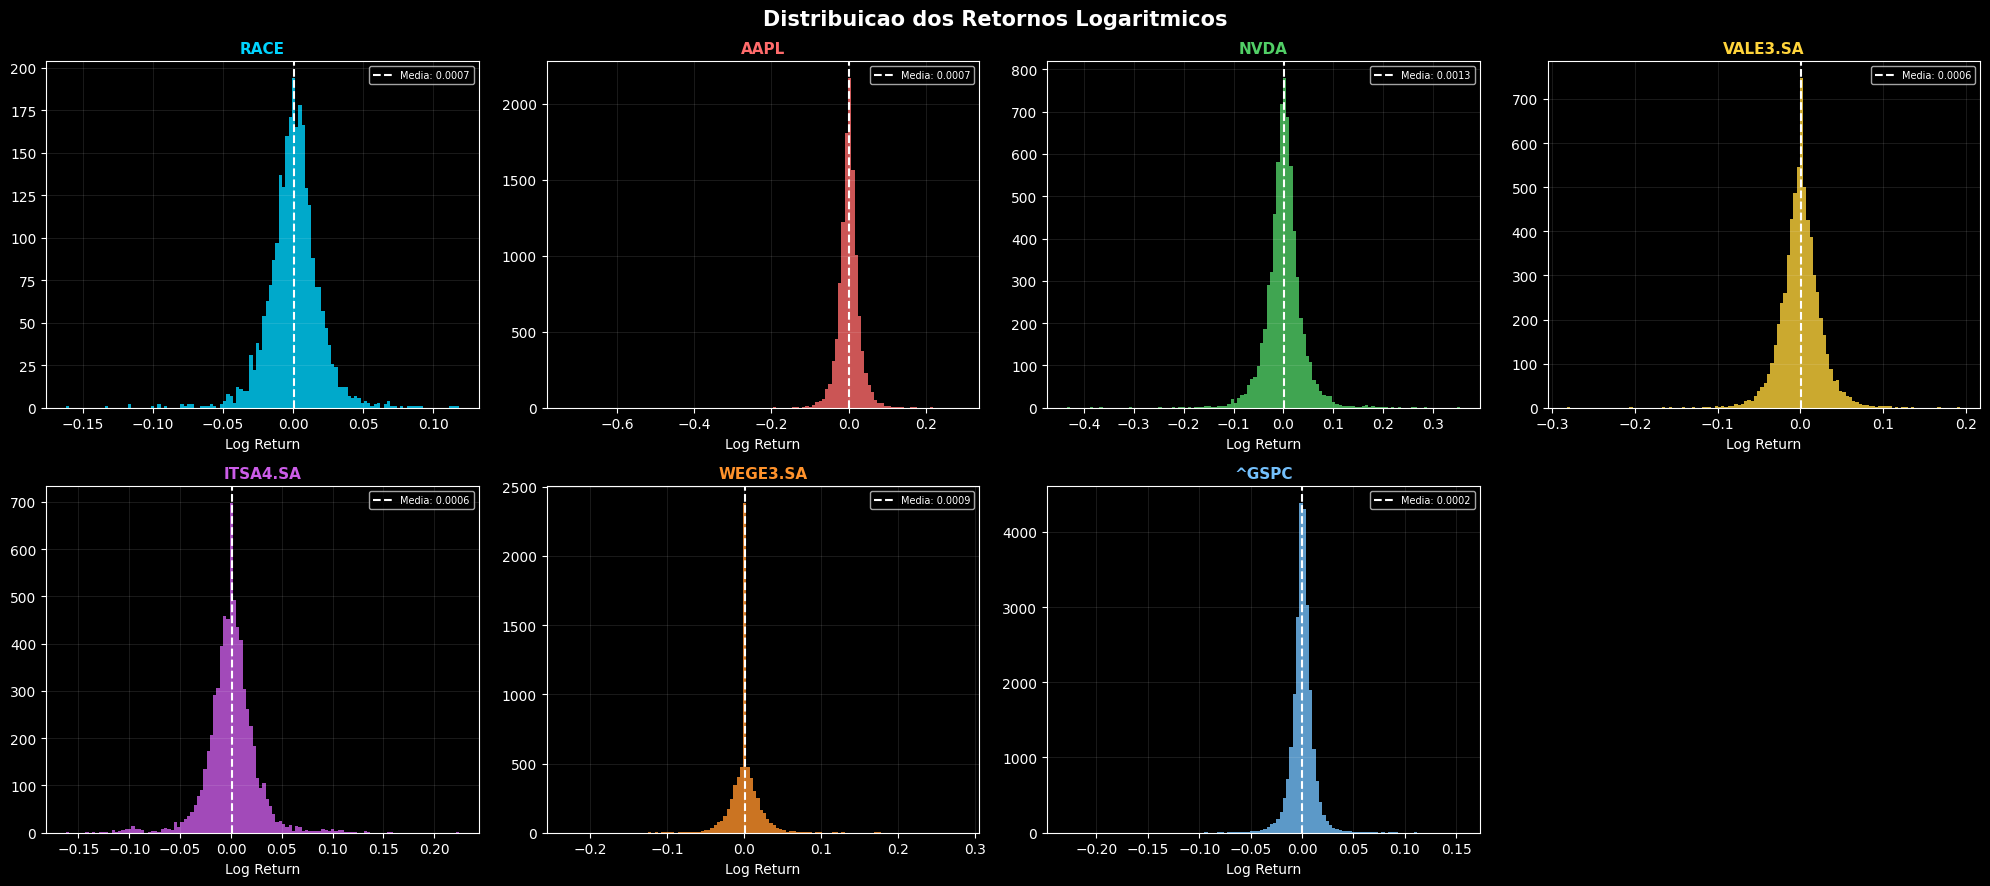

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, (ticker, df) in enumerate(raw.items()):
    ax = axes[i]
    lr = np.log(df["Close"] / df["Close"].shift(1)).dropna()
    ax.hist(lr, bins=120, color=COLORS[i], alpha=0.8, edgecolor="none")
    ax.axvline(lr.mean(), color="white", linestyle="--", linewidth=1.5, label=f"Media: {lr.mean():.4f}")
    ax.set_title(f"{ticker}", fontsize=11, fontweight="bold", color=COLORS[i])
    ax.set_xlabel("Log Return")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.1)
axes[-1].set_visible(False)
fig.suptitle("Distribuicao dos Retornos Logaritmicos", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [6]:
from scipy.stats import kurtosis, skew
rows2 = []
for ticker, df in raw.items():
    lr = np.log(df["Close"] / df["Close"].shift(1)).dropna()
    rows2.append({
        "Ticker": ticker,
        "Media Diaria": round(lr.mean(), 5),
        "Std": round(lr.std(), 5),
        "Min": round(lr.min(), 4),
        "Max": round(lr.max(), 4),
        "Skewness": round(skew(lr), 3),
        "Kurtosis": round(kurtosis(lr), 3),
        "Sharpe Aprox": round(lr.mean() / lr.std() * np.sqrt(252), 3)
    })
pd.DataFrame(rows2).set_index("Ticker")


,Media Diaria,Std,Min,Max,Skewness,Kurtosis,Sharpe Aprox
Ticker,,,,,,,
RACE,0.0007,0.0191,-0.1624,0.1185,-0.3350,7.6020,0.5980
AAPL,0.0007,0.0280,-0.7312,0.2869,-1.7320,48.1980,0.3970
NVDA,0.0013,0.0372,-0.4344,0.3536,-0.1540,12.2240,0.5370
VALE3.SA,0.0006,0.0246,-0.2818,0.1936,-0.1730,7.0230,0.4030
ITSA4.SA,0.0006,0.0246,-0.1625,0.2243,0.0740,6.9810,0.3740
WEGE3.SA,0.0009,0.0205,-0.2309,0.2792,1.3180,25.9690,0.7050
^GSPC,0.0002,0.0119,-0.2290,0.1537,-0.4660,18.7430,0.3250


---
## 5. Correlacao entre os Ativos

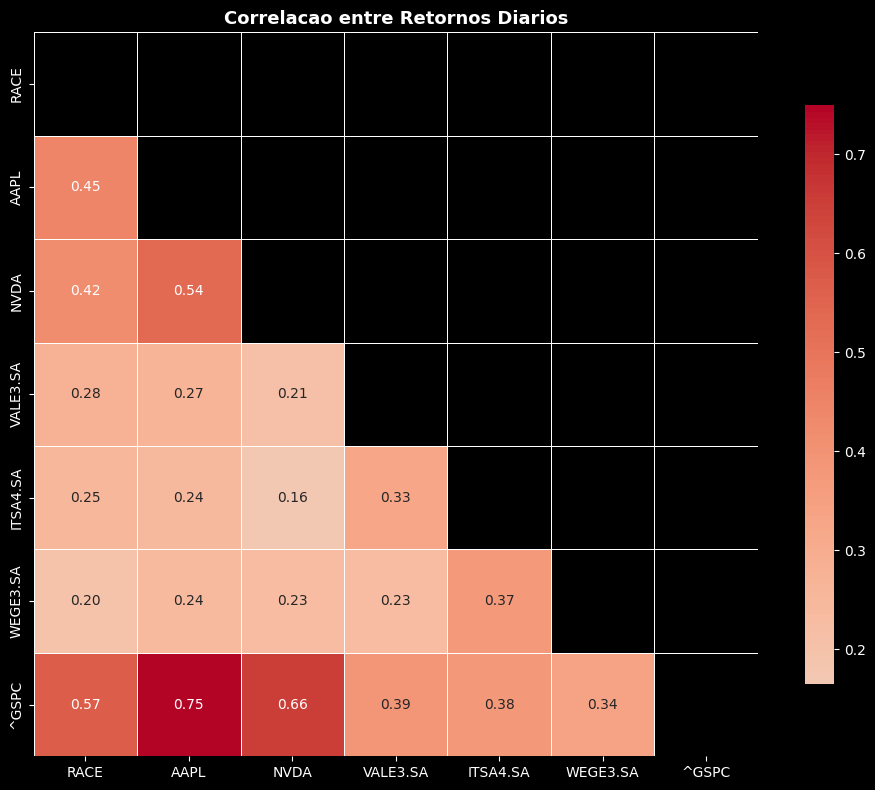

In [7]:
returns = pd.DataFrame({
    ticker: np.log(df["Close"] / df["Close"].shift(1))
    for ticker, df in raw.items()
}).dropna()

fig, ax = plt.subplots(figsize=(10, 8))
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True, cbar_kws={"shrink":0.8})
ax.set_title("Correlacao entre Retornos Diarios", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 6. Volatilidade Realizada (Rolling 30 dias, Anualizada)

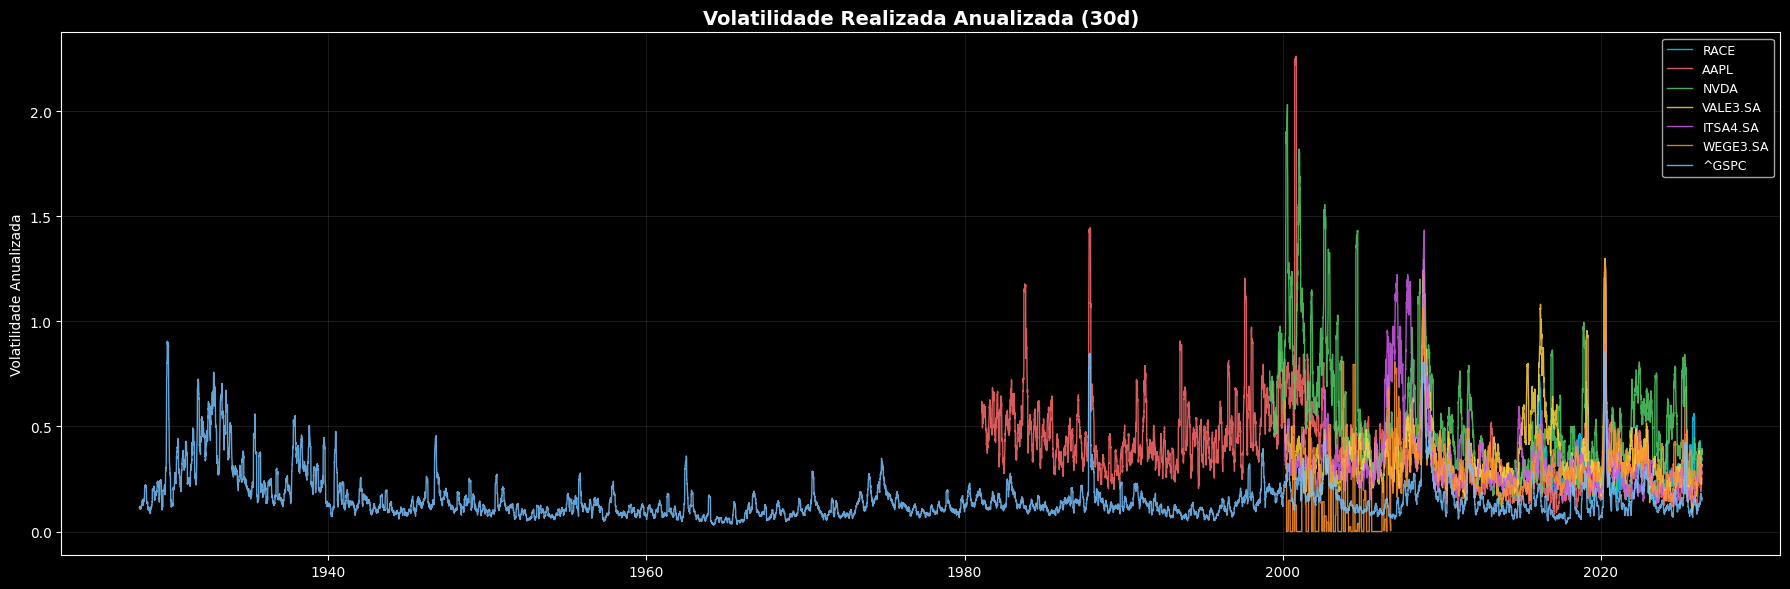

In [8]:
fig, ax = plt.subplots(figsize=(18, 6))
for i, (ticker, df) in enumerate(raw.items()):
    lr = np.log(df["Close"] / df["Close"].shift(1))
    vol = lr.rolling(30).std() * np.sqrt(252)
    ax.plot(vol.index, vol, label=ticker, color=COLORS[i], linewidth=1, alpha=0.85)
ax.set_title("Volatilidade Realizada Anualizada (30d)", fontsize=14, fontweight="bold")
ax.set_ylabel("Volatilidade Anualizada")
ax.legend(fontsize=9)
ax.grid(alpha=0.1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


---
## 7. Feature Engineering

Usamos RACE como ativo de referencia para inspecionar cada feature criada.

In [10]:
df_race = raw["RACE"].copy()

df_race["Log_Return"]        = np.log(df_race["Close"] / df_race["Close"].shift(1))
df_race["Target_Log_Return"] = df_race["Log_Return"].shift(-1)

for lag in [1, 2, 3, 5]:
    df_race[f"Lag_{lag}"] = df_race["Log_Return"].shift(lag)

df_race["SMA_20"]            = df_race["Close"].rolling(20).mean()
df_race["SMA_50"]            = df_race["Close"].rolling(50).mean()
df_race["Std_20"]            = df_race["Close"].rolling(20).std()
df_race["Rolling_Std_14"]    = df_race["Log_Return"].rolling(14).std()
df_race["Distancia_SMA_20"]  = (df_race["Close"] / df_race["SMA_20"]) - 1
df_race["Distancia_SMA_50"]  = (df_race["Close"] / df_race["SMA_50"]) - 1
df_race["Bollinger_Width"]   = (4 * df_race["Std_20"]) / df_race["SMA_20"]

obv_signal = np.where(df_race["Close"] > df_race["Close"].shift(1),
                       df_race["Volume"],
                       np.where(df_race["Close"] < df_race["Close"].shift(1), -df_race["Volume"], 0))
df_race["OBV"]          = obv_signal.cumsum()
df_race["Volume_Shock"] = df_race["Volume"] / df_race["Volume"].rolling(10).mean()
df_race["Volume_ROC_5"] = (df_race["Volume"] / df_race["Volume"].shift(5)) - 1
df_race["OBV_ROC_5"]    = (df_race["OBV"]    / df_race["OBV"].shift(5))    - 1

delta = df_race["Close"].diff()
gain  = delta.where(delta > 0, 0).ewm(span=14, adjust=False).mean()
loss  = (-delta.where(delta < 0, 0)).ewm(span=14, adjust=False).mean()
df_race["RSI_14"] = 100 - (100 / (1 + gain / loss))

ema12 = df_race["Close"].ewm(span=12, adjust=False).mean()
ema26 = df_race["Close"].ewm(span=26, adjust=False).mean()
df_race["MACD_Line"]      = ema12 - ema26
df_race["MACD_Signal"]    = df_race["MACD_Line"].ewm(span=9, adjust=False).mean()
df_race["MACD_Histogram"] = df_race["MACD_Line"] - df_race["MACD_Signal"]

prev_close = df_race["Close"].shift(1)
tr = pd.concat([df_race["High"] - df_race["Low"],
                (df_race["High"] - prev_close).abs(),
                (df_race["Low"]  - prev_close).abs()], axis=1).max(axis=1)
df_race["ATR_14"]  = tr.rolling(14).mean()
df_race["ATR_Pct"] = df_race["ATR_14"] / df_race["Close"]

df_race["Month"]     = df_race.index.month
df_race["DayOfWeek"] = df_race.index.dayofweek
df_race["Month_Sin"] = np.sin(2 * np.pi * df_race["Month"]     / 12)
df_race["Month_Cos"] = np.cos(2 * np.pi * df_race["Month"]     / 12)
df_race["Day_Sin"]   = np.sin(2 * np.pi * df_race["DayOfWeek"] / 5)
df_race["Day_Cos"]   = np.cos(2 * np.pi * df_race["DayOfWeek"] / 5)

df_race_clean = df_race.dropna()
print(f"Shape final: {df_race_clean.shape}")
df_race_clean.tail(3)


Shape final: (2602, 36)


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Log_Return,Target_Log_Return,Lag_1,...,MACD_Signal,MACD_Histogram,ATR_14,ATR_Pct,Month,DayOfWeek,Month_Sin,Month_Cos,Day_Sin,Day_Cos
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-05,333.5000,333.7900,322.6050,325.4400,1159200,0.0000,0.0000,-0.0406,0.0327,-0.0069,...,1.8043,-3.0937,9.2206,0.0283,5,1,0.5000,-0.8660,0.9511,0.3090
2026-05-06,337.0000,338.6000,332.6600,336.2500,673200,0.0000,0.0000,0.0327,0.0036,-0.0406,...,1.0952,-2.8363,9.6416,0.0287,5,2,0.5000,-0.8660,0.5878,-0.8090
2026-05-07,339.0100,342.8700,335.8000,337.4600,696700,0.0000,0.0000,0.0036,0.0066,0.0327,...,0.4805,-2.4590,8.5133,0.0252,5,3,0.5000,-0.8660,-0.5878,-0.8090


### 7.1 Indicadores Tecnicos — Ultimos 500 dias

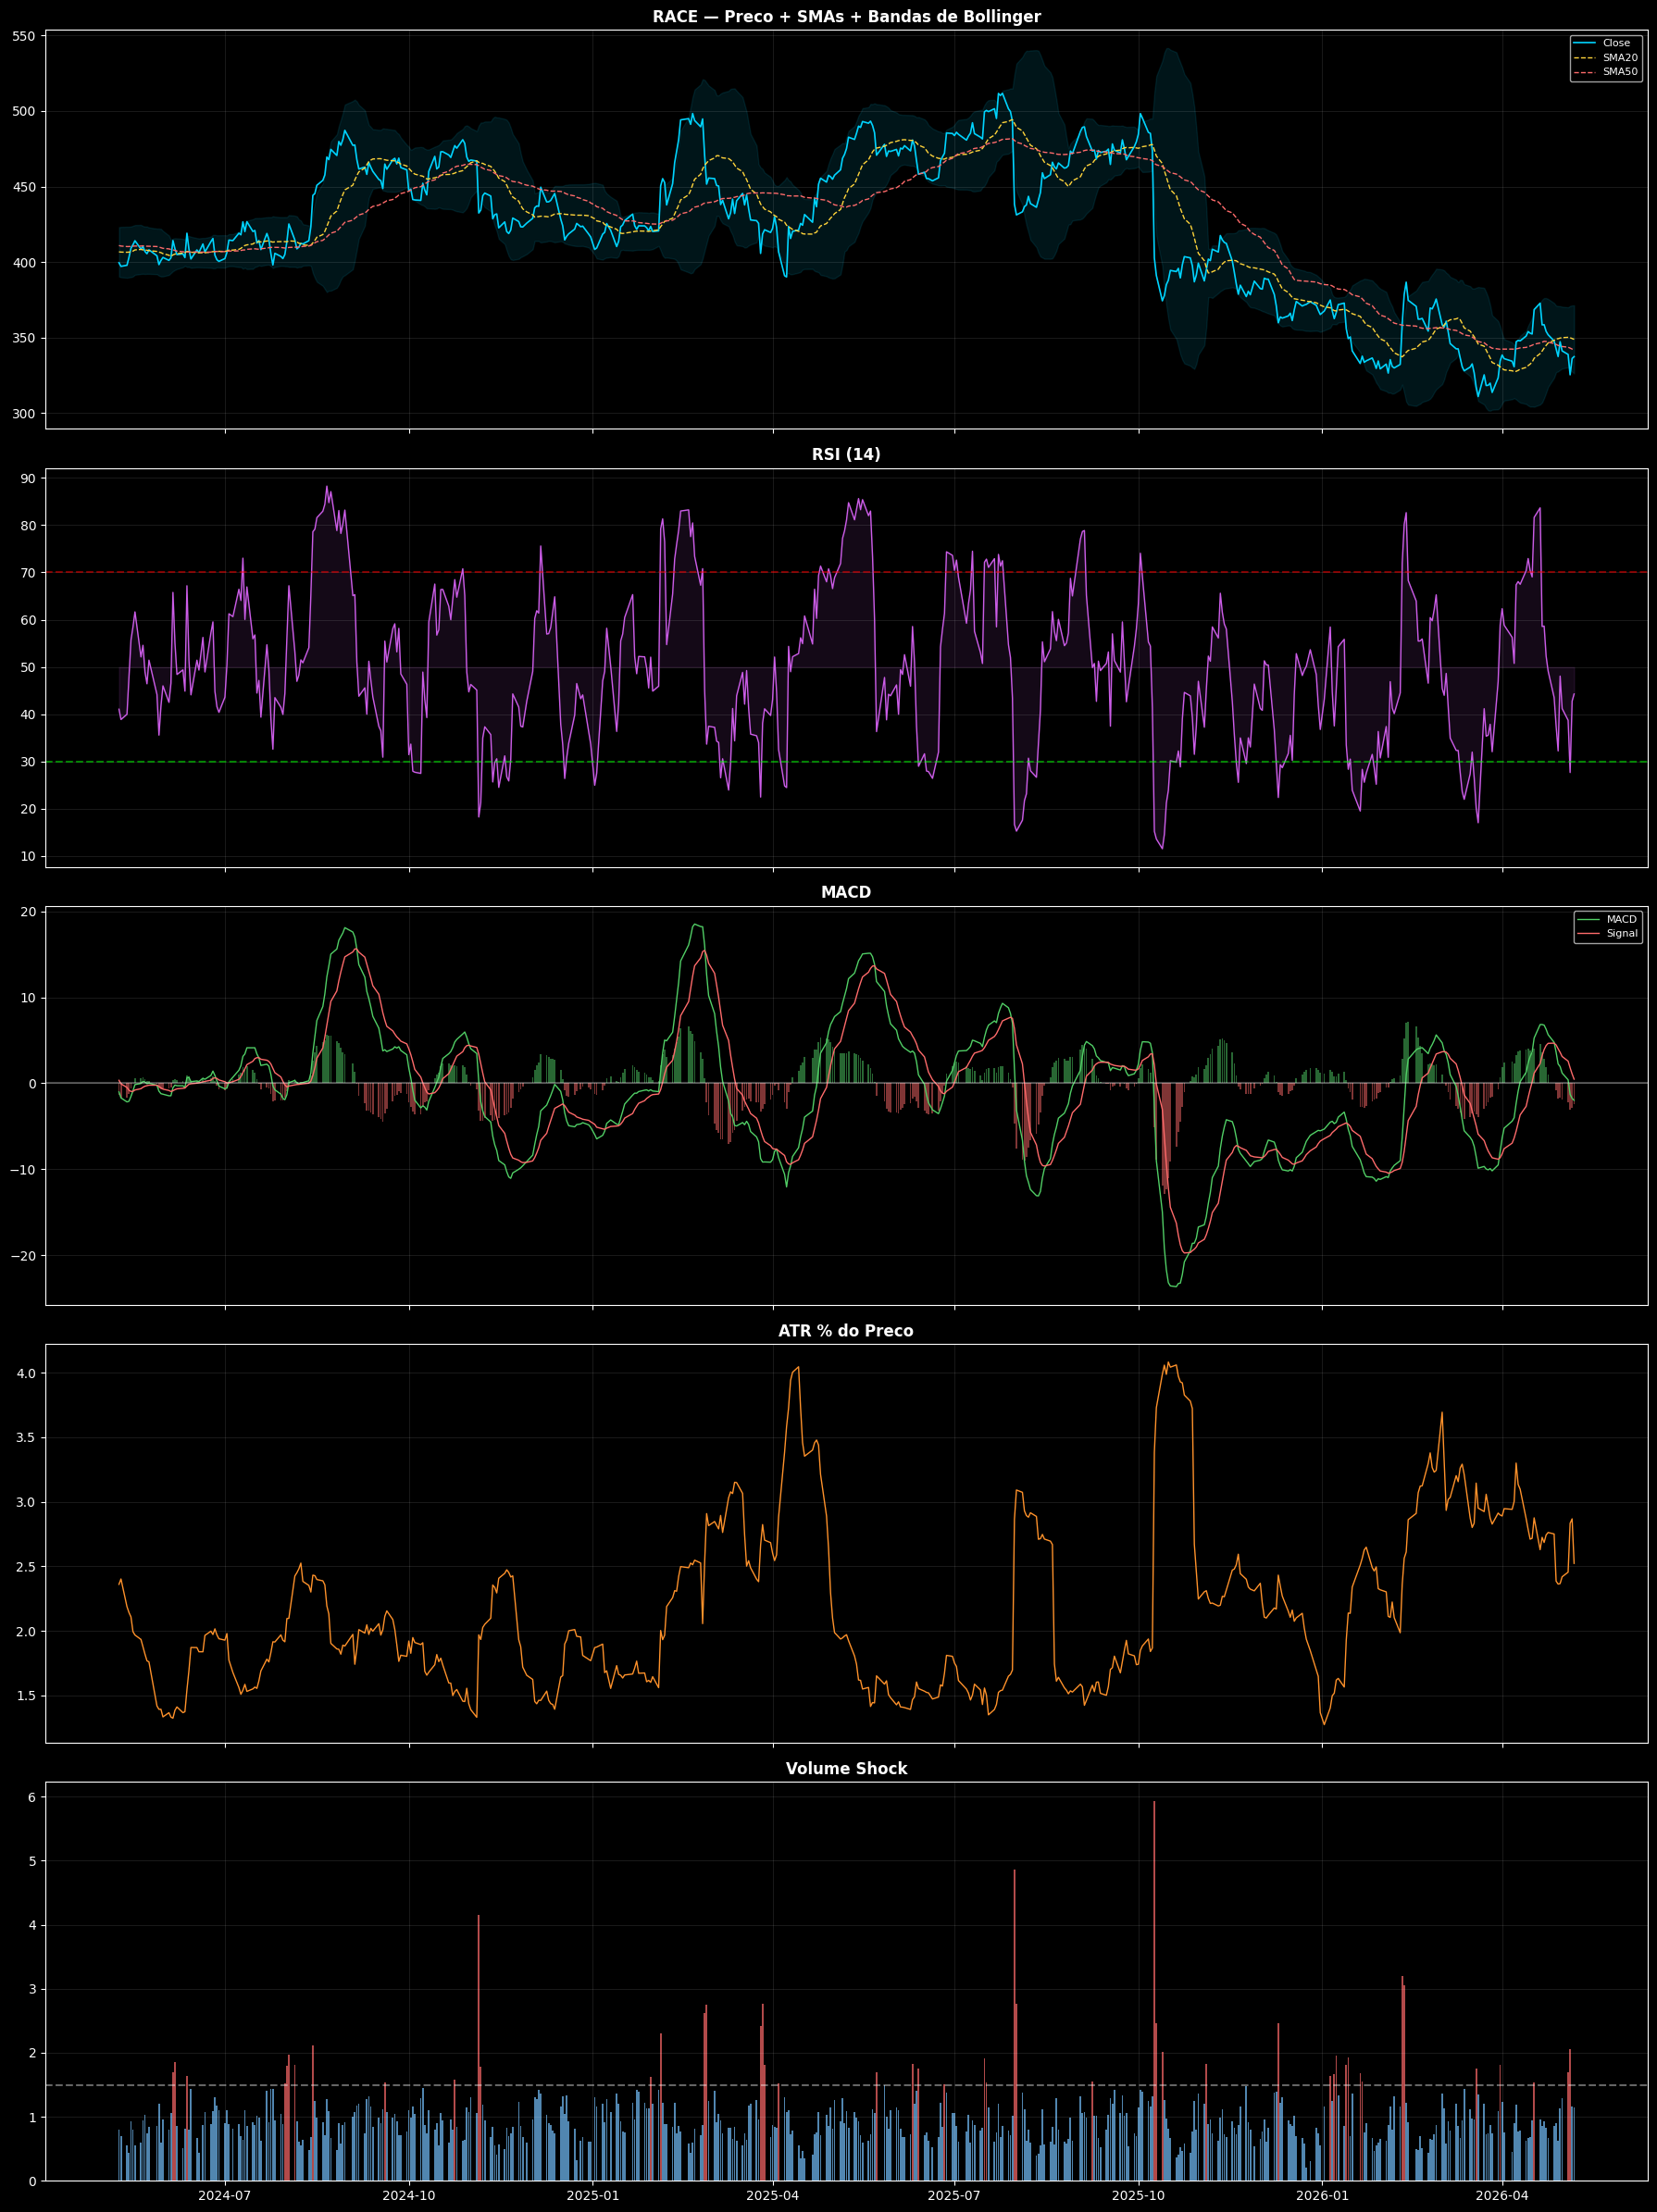

In [12]:
df_plot = df_race.tail(500)
fig, axes = plt.subplots(5, 1, figsize=(18, 25), sharex=True)

axes[0].plot(df_plot.index, df_plot["Close"],  color="white", linewidth=2, label="Preco")
axes[0].plot(df_plot.index, df_plot["SMA_20"], color="#00D4FF", alpha=0.8, label="SMA 20")
axes[0].plot(df_plot.index, df_plot["SMA_50"], color="#FF922B", alpha=0.8, label="SMA 50")
axes[0].fill_between(df_plot.index, df_plot["SMA_20"] - 2*df_plot["Std_20"], df_plot["SMA_20"] + 2*df_plot["Std_20"], color="#00D4FF", alpha=0.1)
axes[0].set_title("RACE — Preco + SMAs + Bandas de Bollinger", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.1)

axes[1].plot(df_plot.index, df_plot["RSI_14"], color="#CC5DE8", linewidth=1)
axes[1].axhline(70, color="red",  alpha=0.5, linestyle="--")
axes[1].axhline(30, color="lime", alpha=0.5, linestyle="--")
axes[1].fill_between(df_plot.index, df_plot["RSI_14"], 50, alpha=0.1, color="#CC5DE8")
axes[1].set_title("RSI (14)", fontweight="bold")
axes[1].grid(alpha=0.1)

axes[2].plot(df_plot.index, df_plot["MACD_Line"],   color="#51CF66", linewidth=1, label="MACD")
axes[2].plot(df_plot.index, df_plot["MACD_Signal"], color="#FF6B6B", linewidth=1, label="Signal")
hist_colors = ["#51CF66" if v >= 0 else "#FF6B6B" for v in df_plot["MACD_Histogram"]]
axes[2].bar(df_plot.index, df_plot["MACD_Histogram"], color=hist_colors, alpha=0.5)
axes[2].axhline(0, color="white", alpha=0.3)
axes[2].set_title("MACD", fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.1)

axes[3].plot(df_plot.index, df_plot["ATR_Pct"] * 100, color="#FF922B", linewidth=1)
axes[3].set_title("ATR % do Preco", fontweight="bold")
axes[3].grid(alpha=0.1)

shock_colors = ["#FF6B6B" if v > 1.5 else "#74C0FC" for v in df_plot["Volume_Shock"]]
axes[4].bar(df_plot.index, df_plot["Volume_Shock"], color=shock_colors, alpha=0.7)
axes[4].axhline(1.5, color="white", alpha=0.4, linestyle="--")
axes[4].set_title("Volume Shock", fontweight="bold")
axes[4].grid(alpha=0.1)

plt.tight_layout()
plt.show()

---
## 8. Correlacao das Features com o Target

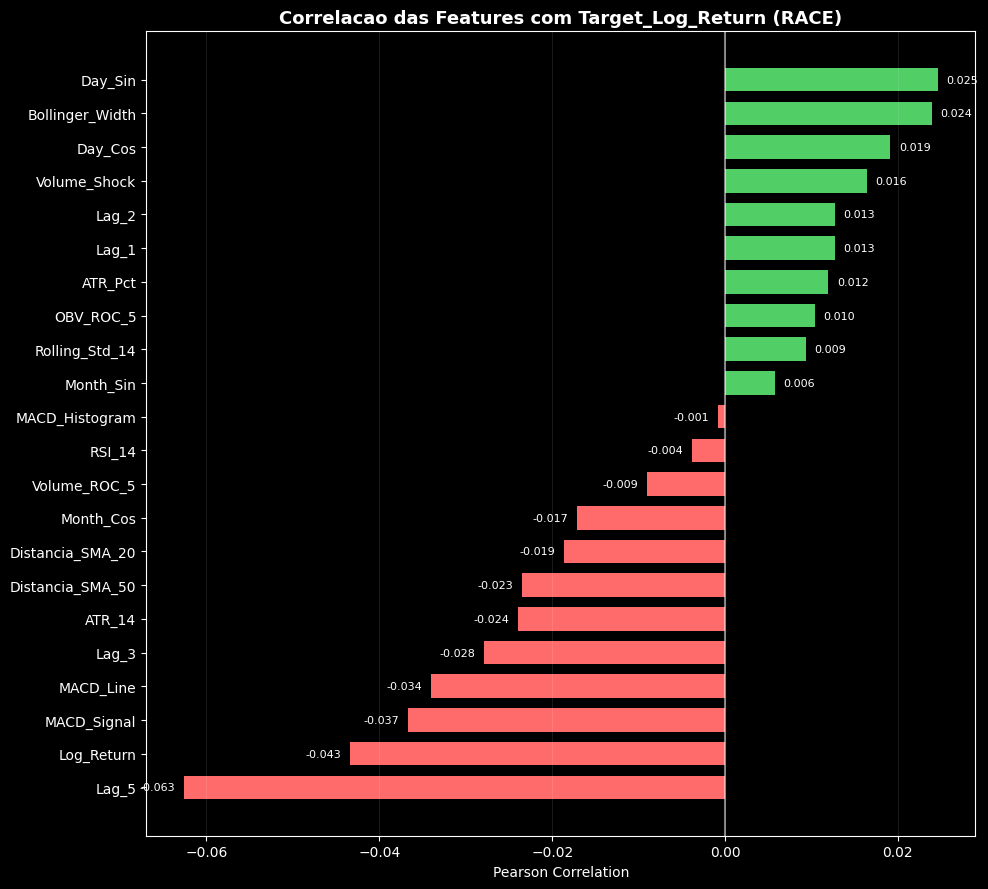

In [13]:
FEATURES = [
    "Log_Return","Lag_1","Lag_2","Lag_3","Lag_5",
    "Rolling_Std_14","Distancia_SMA_20","Distancia_SMA_50","Bollinger_Width",
    "Volume_Shock","Volume_ROC_5","OBV_ROC_5",
    "RSI_14","MACD_Line","MACD_Signal","MACD_Histogram","ATR_14","ATR_Pct",
    "Month_Sin","Month_Cos","Day_Sin","Day_Cos"
]
TARGET = "Target_Log_Return"

corr_target = df_race_clean[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ["#FF6B6B" if v < 0 else "#51CF66" for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor="none", height=0.7)
ax.axvline(0, color="white", alpha=0.5)
ax.set_title("Correlacao das Features com Target_Log_Return (RACE)", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
for bar, val in zip(bars, corr_target.values):
    ha = "left" if val >= 0 else "right"
    ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha, fontsize=8)
ax.grid(axis="x", alpha=0.1)
plt.tight_layout()
plt.show()


---
## 9. Autocorrelacao dos Retornos (ACF / PACF)

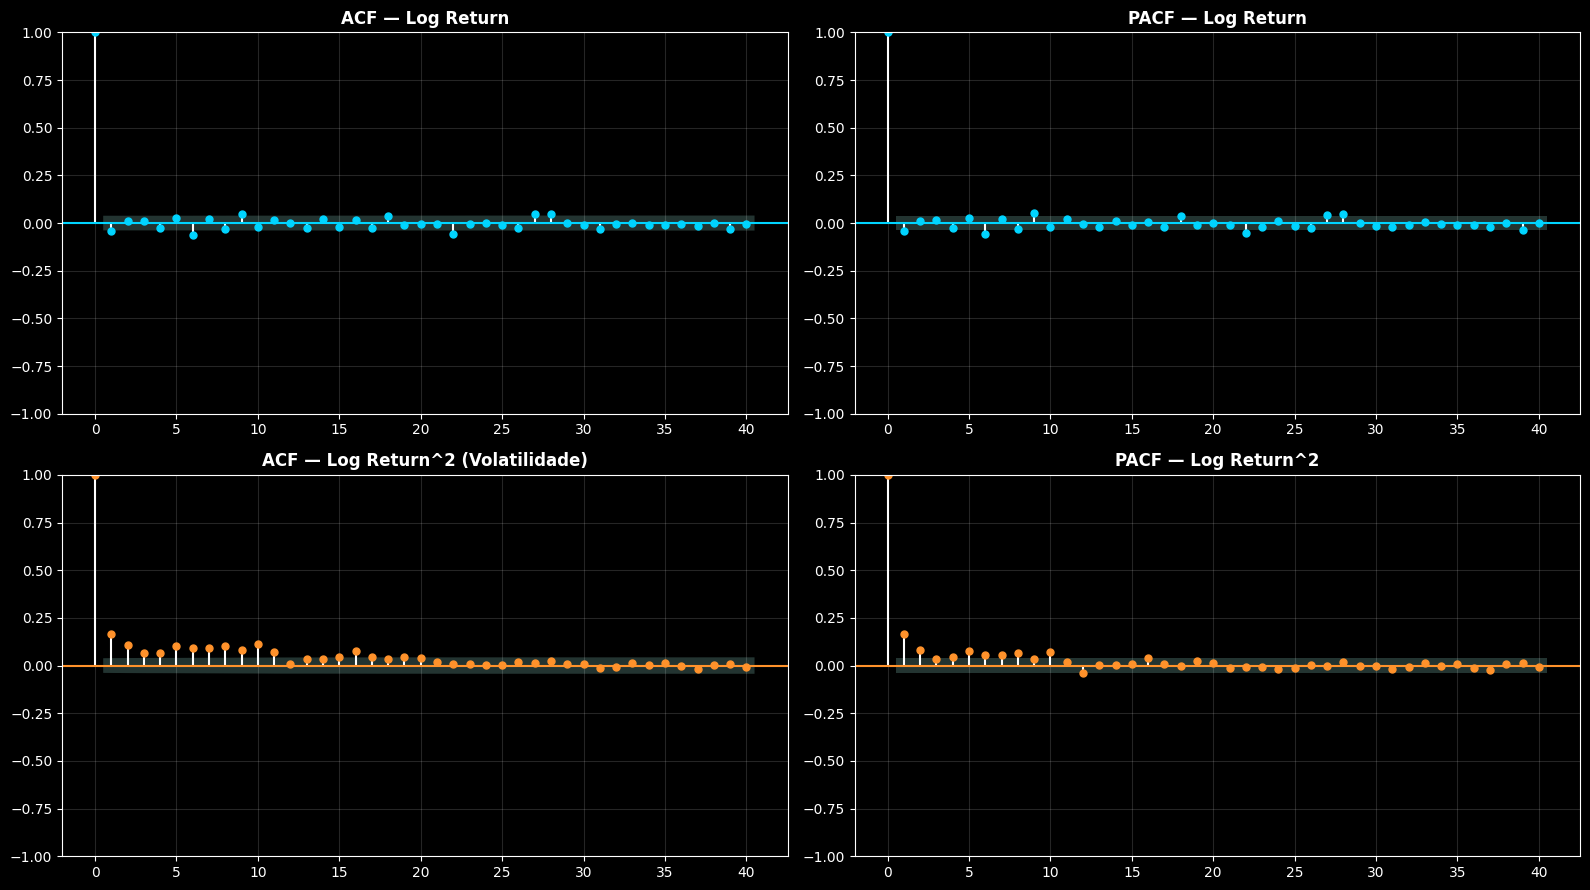

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
lr = raw["RACE"]["Log_Return"].dropna()
lr_sq = lr**2

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
plot_acf(lr,    lags=40, ax=axes[0,0], color="#00D4FF")
axes[0,0].set_title("ACF — Log Return", fontweight="bold")
plot_pacf(lr,   lags=40, ax=axes[0,1], color="#00D4FF")
axes[0,1].set_title("PACF — Log Return", fontweight="bold")
plot_acf(lr_sq, lags=40, ax=axes[1,0], color="#FF922B")
axes[1,0].set_title("ACF — Log Return^2 (Volatilidade)", fontweight="bold")
plot_pacf(lr_sq,lags=40, ax=axes[1,1], color="#FF922B")
axes[1,1].set_title("PACF — Log Return^2", fontweight="bold")

for ax in axes.flatten():
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

---
## 10. Sazonalidade por Dia da Semana e Mes

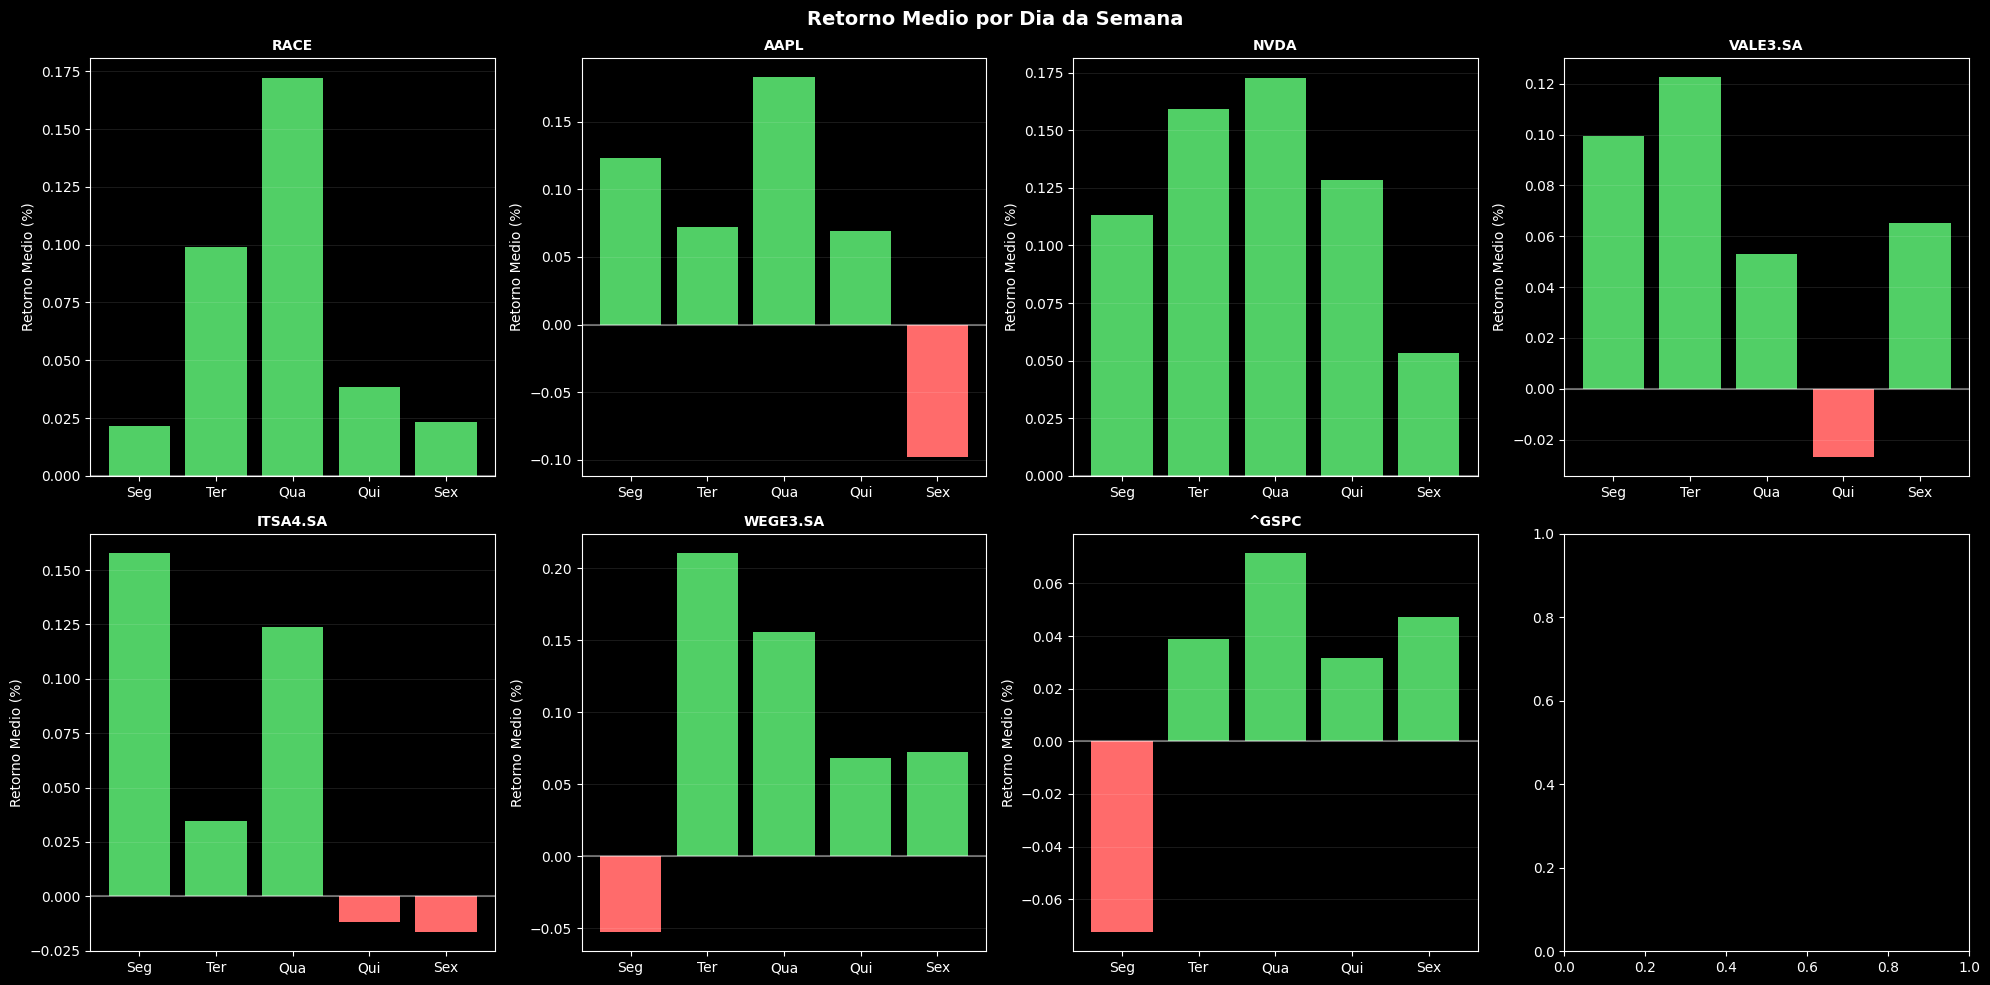

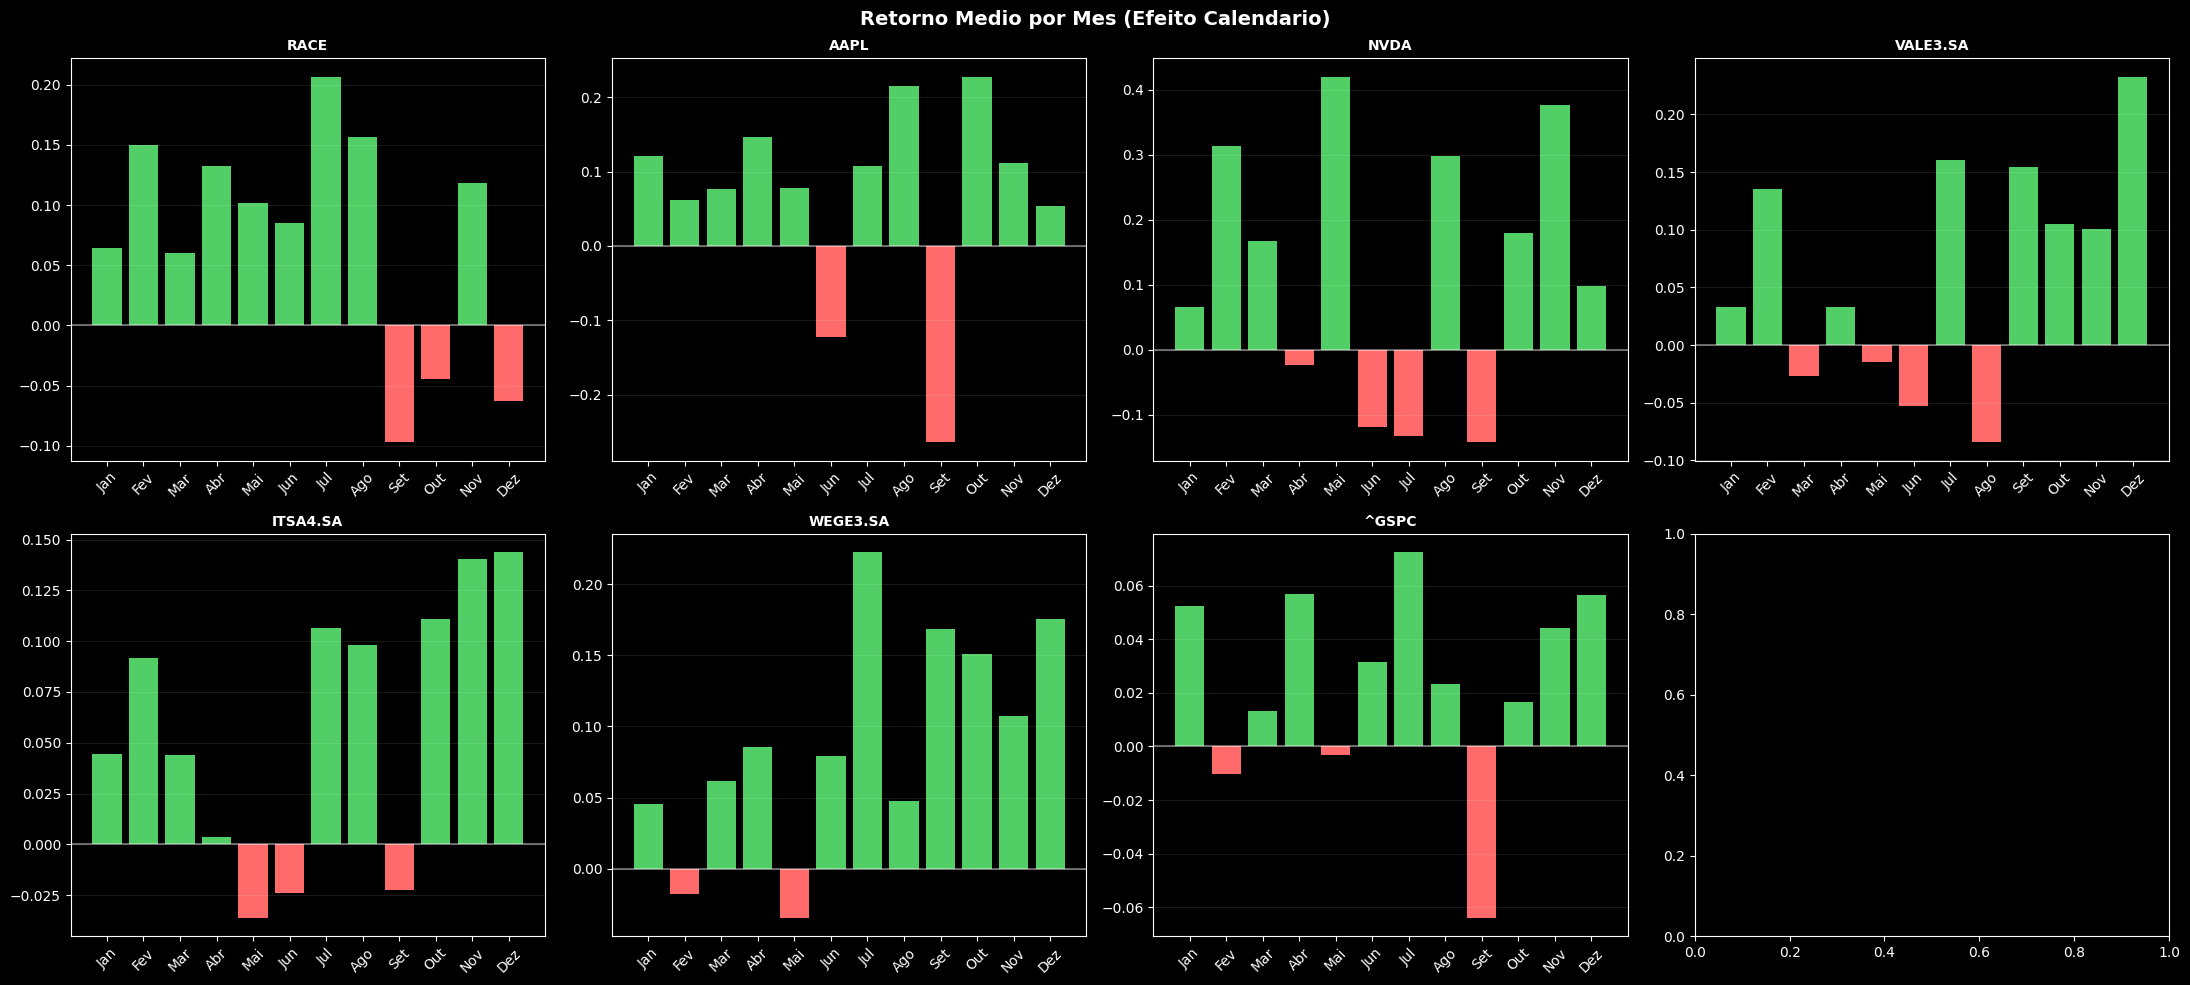

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for i, (ticker, df) in enumerate(raw.items()):
    ax = axes[i//4, i%4]
    day_ret = df.groupby("DayOfWeek")["Log_Return"].mean() * 100
    day_ret.plot(kind="bar", ax=ax, color="#74C0FC", alpha=0.8)
    ax.set_title(ticker, fontweight="bold")
    ax.axhline(0, color="white", alpha=0.5)
    ax.grid(alpha=0.1)
fig.suptitle("Retorno Medio por Dia da Semana", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 4, figsize=(22, 10))
for i, (ticker, df) in enumerate(raw.items()):
    ax = axes2[i//4, i%4]
    month_ret = df.groupby("Month")["Log_Return"].mean() * 100
    month_ret.plot(kind="bar", ax=ax, color="#FFD43B", alpha=0.8)
    ax.set_title(ticker, fontweight="bold")
    ax.axhline(0, color="white", alpha=0.5)
    ax.grid(alpha=0.1)
fig2.suptitle("Retorno Medio por Mes (Efeito Calendario)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 11. Drawdown Historico

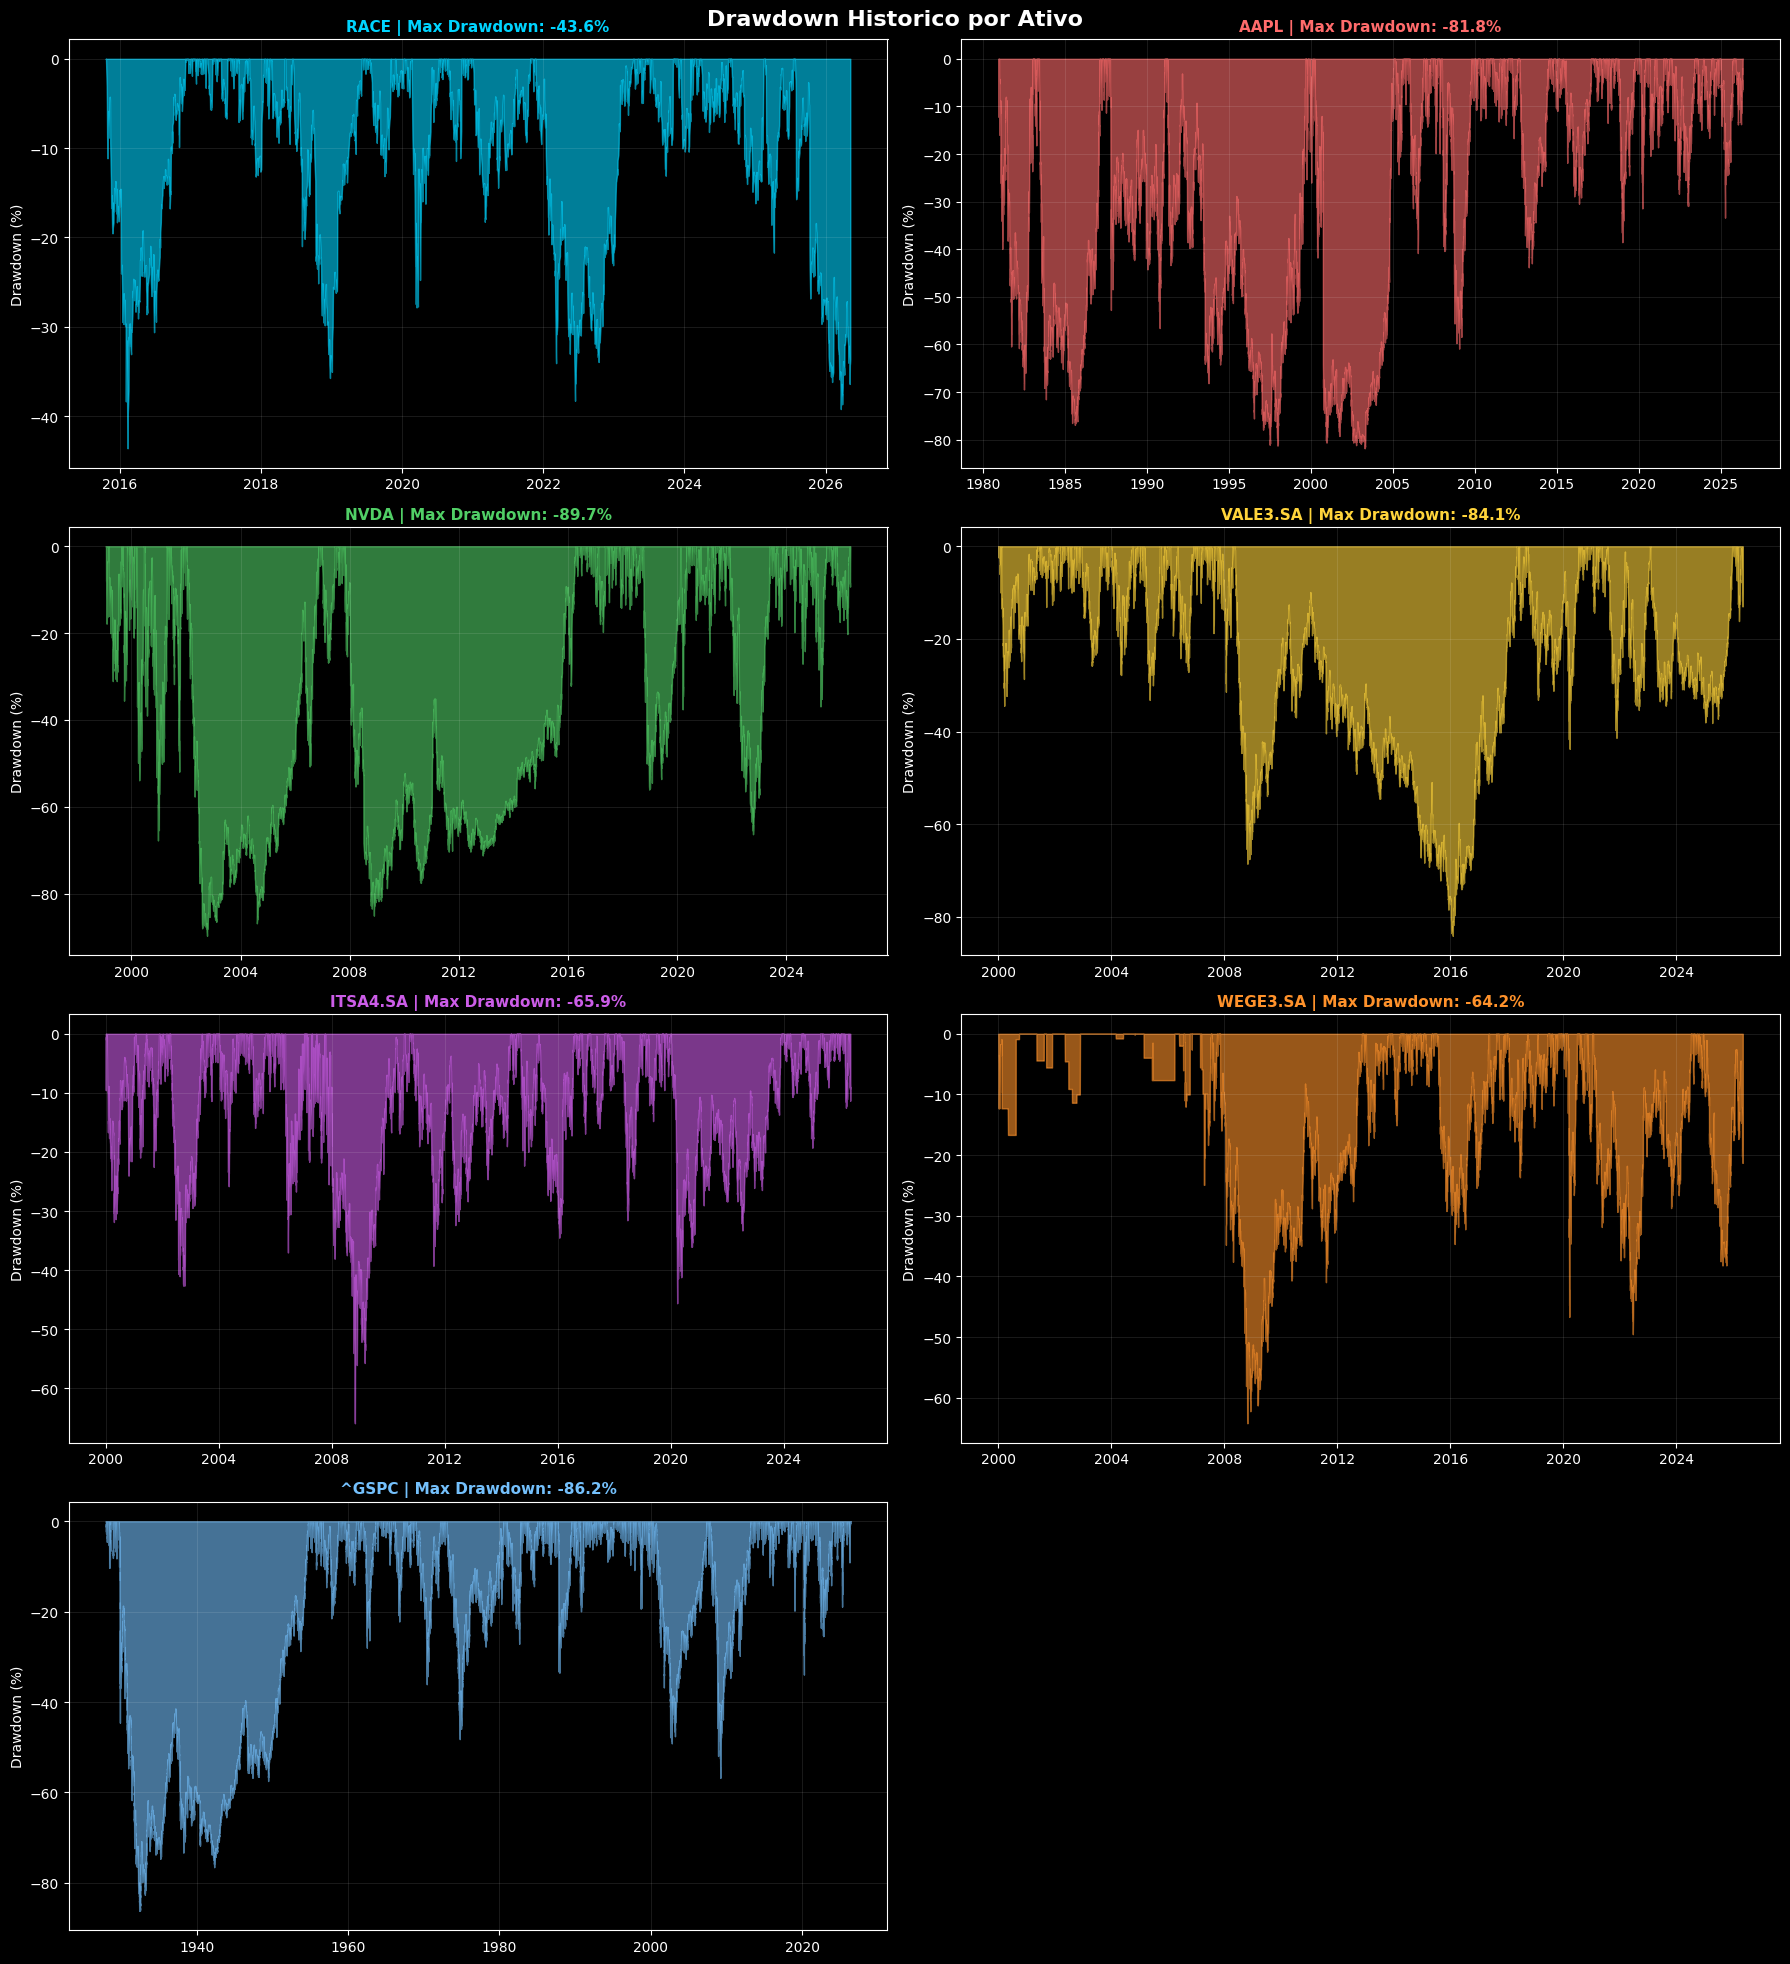

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()
for i, (ticker, df) in enumerate(raw.items()):
    ax = axes[i]
    roll_max = df["Close"].cummax()
    dd = (df["Close"] / roll_max) - 1
    ax.fill_between(dd.index, dd, 0, color="#FF6B6B", alpha=0.3)
    ax.plot(dd.index, dd, color="#FF6B6B", linewidth=1)
    ax.set_title(f"{ticker} — Max Drawdown: {dd.min():.2%}", fontweight="bold")
    ax.grid(alpha=0.1)
fig.suptitle("Drawdown Historico por Ativo", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 12. Conclusoes e Implicacoes para o Modelo

| # | Observacao | Implicacao para o Modelo |
|---|---|---|
| 1 | Retornos leptocurticos (caudas grossas) | MinMaxScaler suaviza extremos; modelo sensivel a outliers |
| 2 | Autocorrelacao significativa ate lag ~3 | Justifica Lag_1 a Lag_5 e janela temporal de 24 dias |
| 3 | Clustering de volatilidade (retornos^2 correlacionados) | ATR_14 e Rolling_Std_14 sao features essenciais |
| 4 | Sazonalidade leve por dia e mes | Encoding ciclico (sin/cos) captura esse padrao suavemente |
| 5 | Baixa correlacao entre ativos BR e US | Features macro (SP500, VIX, EURUSD) complementam a predicao |
| 6 | RSI e MACD tem correlacao baixa com target | Uteis como indicadores de regime, nao de predicao direta |
| 7 | Drawdowns extremos em 2020 e 2022 | Modelos treinados pre-COVID podem nao generalizar bem |

---
*EDA gerado com base na arquitetura de producao do projeto Financial Asset Price Forecasting.*